# Sepsis HMM — EDA
Analysis of the MIMIC-IV sepsis cohort in preparation for fitting a discrete-time Hidden Markov Model.

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`
**Input:** `cohort_processed.csv`

# Sepsis HMM — EDA
Plots and analysis relevant to building a discrete-time Hidden Markov Model.

**Sections**
1. Setup
2. Sequence Length Distribution
3. Observable State Space
4. Transition Matrix
5. State Dwell-Time Distributions
6. Emission Distributions per State
7. Autocorrelation (Markov Assumption Check)
8. Stationarity — ADF Test
9. Flag Co-occurrence Over Normalised Stay
10. Correlation Matrix

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv("cohort_processed.csv", index_col=0, parse_dates=True) # output from data_processing.py

# Replace sentinel error values
df['WBC']     = df['WBC'].replace(999_999, np.nan)
df['Lactate'] = df['Lactate'].replace(999_999, np.nan)

# Clip to physiologically defensible bounds
CLIP = {'HR': (20, 220), 'MAP': (20, 200), 'SPO2': (50, 100), 'WBC': (0.1, 80), 'Lactate': (0.1, 25)}
for col, (lo, hi) in CLIP.items():
    df[col] = df[col].clip(lo, hi)

flag_cols  = ['oxygenFlag', 'antibioticsFlag', 'cultureFlag', 'vasoFlag']
continuous = ['HR', 'MAP', 'SPO2', 'WBC', 'Lactate']
df[flag_cols] = df[flag_cols].astype(int)

print(f"Rows: {len(df):,}  |  Patients: {df['SubjectId'].nunique():,}")
df.head()

Rows: 88,447  |  Patients: 786


,HR,MAP,SPO2,WBC,Lactate,oxygenFlag,antibioticsFlag,cultureFlag,vasoFlag,WBC_missing,Lactate_missing,SubjectId
2186-02-20 18:00:00,NaN,NaN,NaN,NaN,NaN,2,0,0,0,1,1,14786549
2186-02-20 19:00:00,NaN,NaN,NaN,NaN,NaN,2,0,0,0,1,1,14786549
2186-02-20 20:00:00,NaN,NaN,NaN,NaN,NaN,2,1,0,1,1,1,14786549
2186-02-20 21:00:00,NaN,NaN,NaN,NaN,NaN,0,0,0,0,1,1,14786549
2186-02-20 22:00:00,NaN,NaN,NaN,NaN,NaN,0,0,0,0,1,1,14786549


## 2. Sequence Length Distribution

In a discrete-time HMM each patient is one observation sequence. Knowing the length distribution determines whether padding/truncation is needed and informs library choice (`hmmlearn` handles variable-length sequences natively).

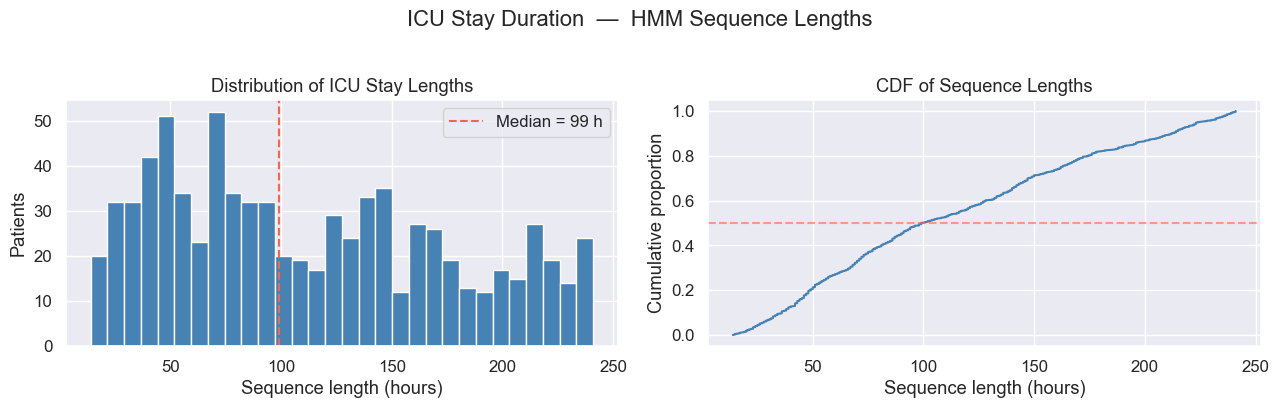

count    786.0
mean     112.5
std       63.8
min       14.0
25%       56.0
50%       99.0
75%      162.0
max      241.0


In [2]:
seq_len = df.groupby('SubjectId').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(seq_len, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(seq_len.median(), color='tomato', ls='--',
                label=f'Median = {seq_len.median():.0f} h')
axes[0].set_xlabel('Sequence length (hours)')
axes[0].set_ylabel('Patients')
axes[0].set_title('Distribution of ICU Stay Lengths')
axes[0].legend()

axes[1].plot(np.sort(seq_len), np.linspace(0, 1, len(seq_len)), color='steelblue')
axes[1].axhline(0.5, color='tomato', ls='--', alpha=0.6)
axes[1].set_xlabel('Sequence length (hours)')
axes[1].set_ylabel('Cumulative proportion')
axes[1].set_title('CDF of Sequence Lengths')

plt.suptitle('ICU Stay Duration  —  HMM Sequence Lengths', y=1.02)
plt.tight_layout()
plt.show()

print(seq_len.describe().round(1).to_string())

## 3. Observable State Space

We define the observed state at each timestep as the combination of oxygen support and vasopressor use — the two strongest acuity signals. These are the emissions the HMM will be conditioned on.

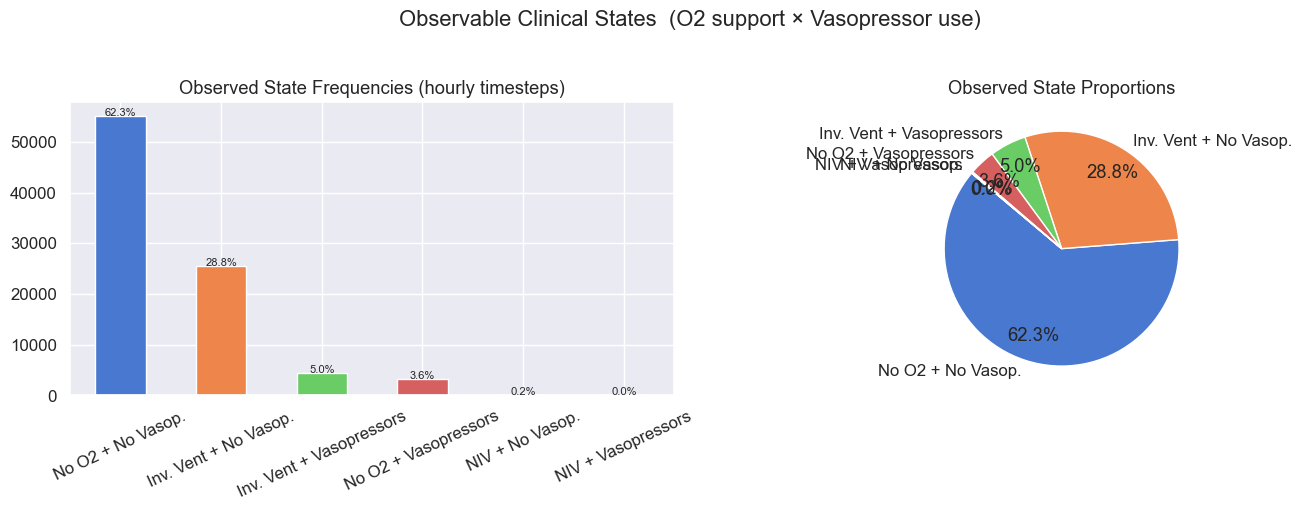

In [3]:
O2_MAP   = {0: 'No O2', 1: 'NIV', 2: 'Inv. Vent'}
VASO_MAP = {0: 'No Vasop.', 1: 'Vasopressors'}

df['obs_state'] = df['oxygenFlag'].map(O2_MAP) + ' + ' + df['vasoFlag'].map(VASO_MAP)

state_counts = df['obs_state'].value_counts()
pct          = state_counts / len(df) * 100
palette      = sns.color_palette("muted", len(state_counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

state_counts.plot(kind='bar', ax=axes[0], color=palette, edgecolor='white')
for bar, p in zip(axes[0].patches, pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{p:.1f}%', ha='center', fontsize=8)
axes[0].set_title('Observed State Frequencies (hourly timesteps)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

axes[1].pie(state_counts, labels=state_counts.index, colors=palette,
            autopct='%1.1f%%', startangle=140, pctdistance=0.78)
axes[1].set_title('Observed State Proportions')

plt.suptitle('Observable Clinical States  (O2 support × Vasopressor use)', y=1.02)
plt.tight_layout()
plt.show()

states = list(state_counts.index)

## 4. Empirical Transition Matrix

The row-normalised matrix gives observed hour-to-hour transition probabilities. This directly initialises (or sanity-checks) the HMM **A** matrix. Strong diagonal dominance means states are "sticky" — expected for hourly ICU data.

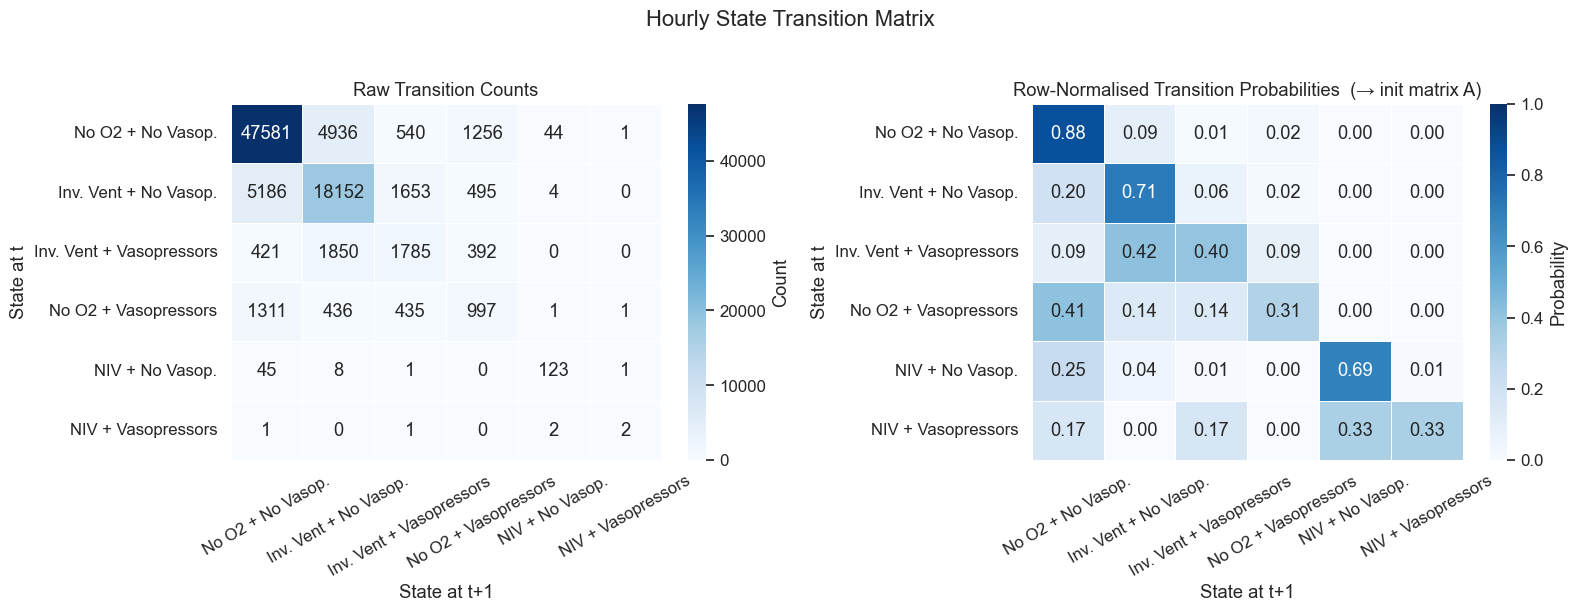

Self-transition (diagonal) probabilities:
No O2 + No Vasop.           0.875
Inv. Vent + No Vasop.       0.712
Inv. Vent + Vasopressors    0.401
No O2 + Vasopressors        0.313
NIV + No Vasop.             0.691
NIV + Vasopressors          0.333


In [4]:
trans = pd.DataFrame(0, index=states, columns=states)

for _, grp in df.groupby('SubjectId', sort=False):
    s = grp['obs_state'].values
    for t in range(len(s) - 1):
        trans.loc[s[t], s[t + 1]] += 1

trans_prob = trans.div(trans.sum(axis=1), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(trans, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.4, cbar_kws={'label': 'Count'})
axes[0].set_title('Raw Transition Counts')
axes[0].set_xlabel('State at t+1')
axes[0].set_ylabel('State at t')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(trans_prob, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            vmin=0, vmax=1, linewidths=0.4, cbar_kws={'label': 'Probability'})
axes[1].set_title('Row-Normalised Transition Probabilities  (→ init matrix A)')
axes[1].set_xlabel('State at t+1')
axes[1].set_ylabel('State at t')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Hourly State Transition Matrix', y=1.02)
plt.tight_layout()
plt.show()

print("Self-transition (diagonal) probabilities:")
print(pd.Series(np.diag(trans_prob.values), index=trans_prob.index).round(3).to_string())

## 5. State Dwell-Time Distributions

How long does each state persist before a switch? A discrete-time HMM assumes **geometric** dwell times (the discrete analogue of exponential). A good fit validates the model; a heavy mode > 1 or long tail suggests a semi-Markov or higher-order HMM may fit better.

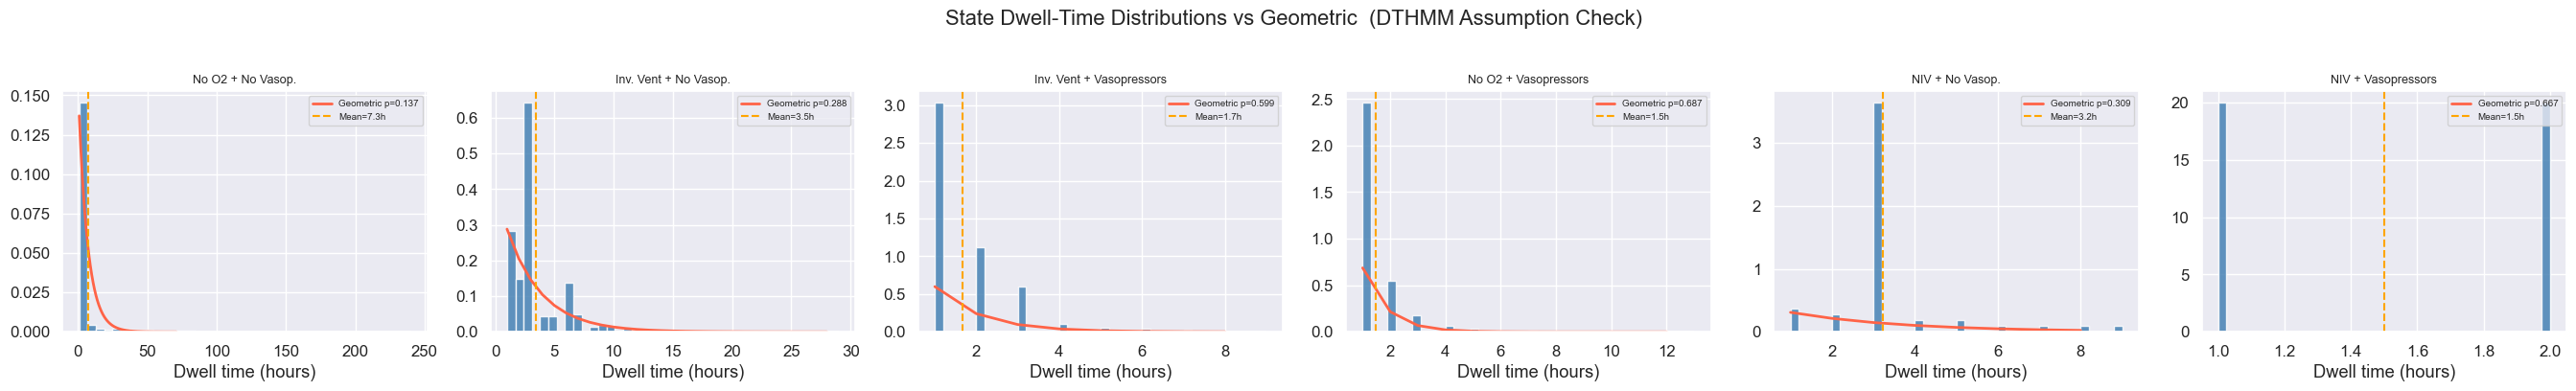

In [5]:
def get_dwells(series):
    runs = []
    cur, cnt = series.iloc[0], 1
    for v in series.iloc[1:]:
        if v == cur:
            cnt += 1
        else:
            runs.append((cur, cnt))
            cur, cnt = v, 1
    runs.append((cur, cnt))
    return runs

all_dwells = {s: [] for s in states}
for _, grp in df.groupby('SubjectId', sort=False):
    for state, length in get_dwells(grp['obs_state'].reset_index(drop=True)):
        if state in all_dwells:
            all_dwells[state].append(length)

n = len(states)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4))
if n == 1:
    axes = [axes]

for ax, state in zip(axes, states):
    d = np.array(all_dwells[state])
    ax.hist(d, bins=40, color='steelblue', edgecolor='white', density=True, alpha=0.85)
    mean_d = d.mean()
    p = 1 / mean_d
    k = np.arange(1, min(d.max(), 72))
    ax.plot(k, (1 - p) ** (k - 1) * p, color='tomato', lw=2,
            label=f'Geometric p={p:.3f}')
    ax.axvline(mean_d, color='orange', ls='--', lw=1.5, label=f'Mean={mean_d:.1f}h')
    ax.set_title(state, fontsize=9)
    ax.set_xlabel('Dwell time (hours)')
    ax.legend(fontsize=7)

plt.suptitle('State Dwell-Time Distributions vs Geometric  (DTHMM Assumption Check)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Emission Distributions per Observed State

These distributions become the **emission parameters** (means and covariances) of a Gaussian HMM. Clearly separated means across states indicate the features are discriminative. Right-skewed features (WBC, Lactate) may benefit from log-transformation.

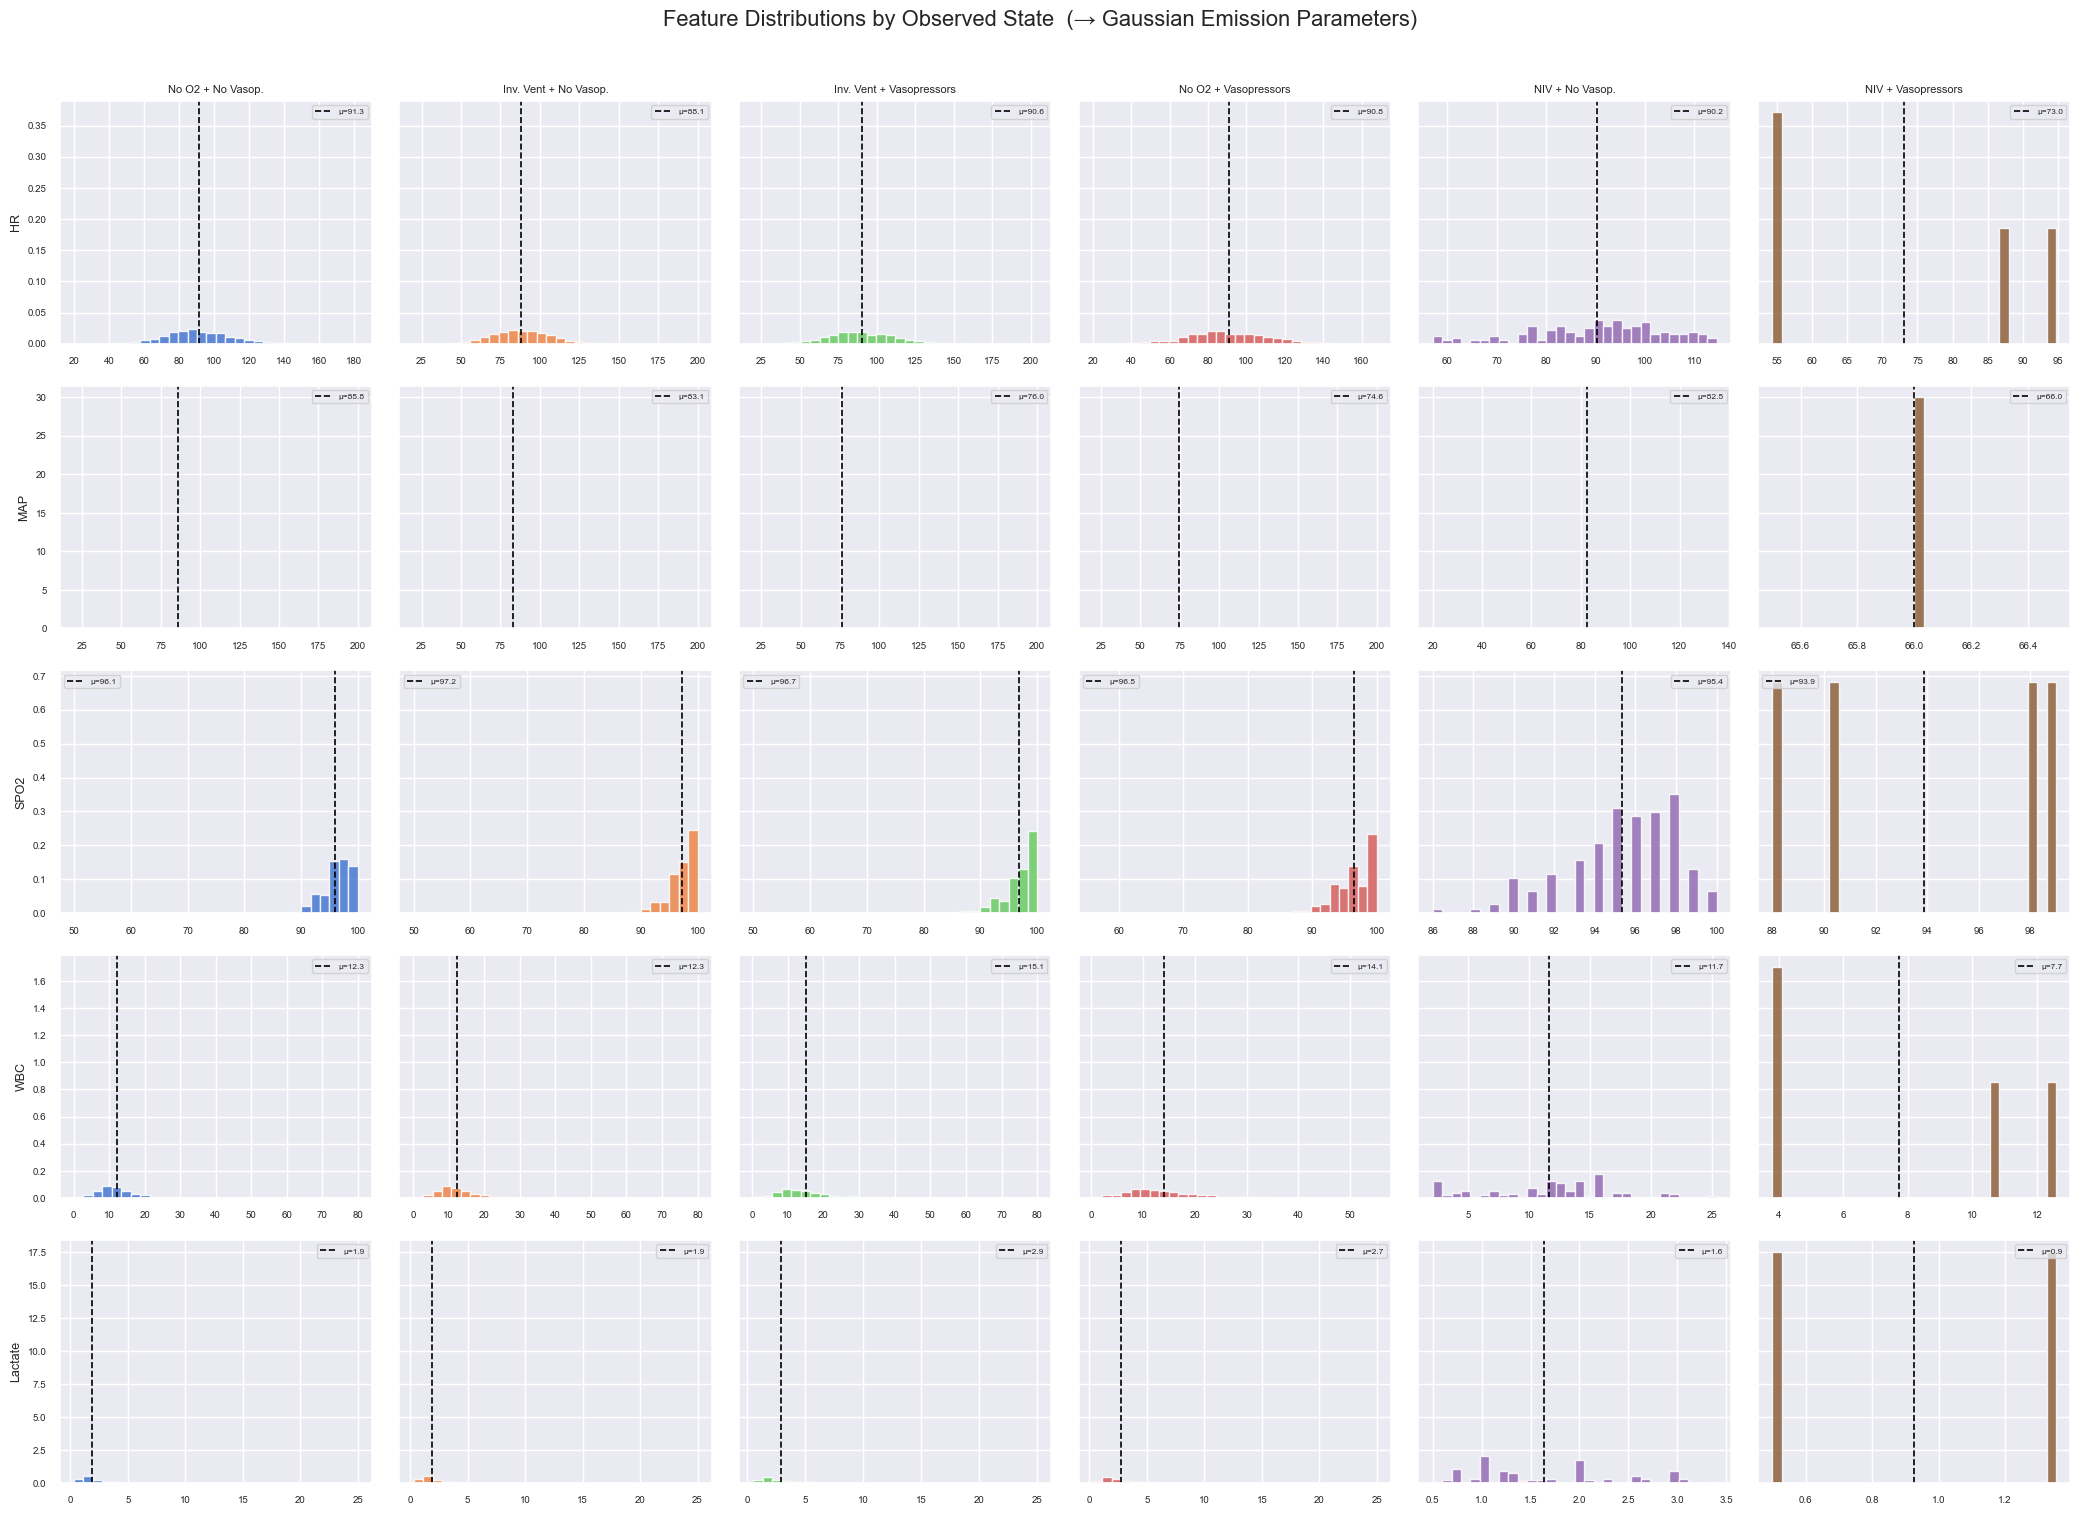

In [6]:
fig, axes = plt.subplots(len(continuous), len(states),
                          figsize=(3.5 * len(states), 3 * len(continuous)),
                          sharey='row')

pal = sns.color_palette("muted", len(states))

for row, feat in enumerate(continuous):
    for col, state in enumerate(states):
        ax   = axes[row][col]
        data = df.loc[df['obs_state'] == state, feat].dropna()
        ax.hist(data, bins=30, color=pal[col], edgecolor='white', density=True, alpha=0.85)
        ax.axvline(data.mean(), color='black', ls='--', lw=1.2,
                   label=f'μ={data.mean():.1f}')
        if row == 0:
            ax.set_title(state, fontsize=8)
        if col == 0:
            ax.set_ylabel(feat, fontsize=9)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=7)

plt.suptitle('Feature Distributions by Observed State  (→ Gaussian Emission Parameters)', y=1.01)
plt.tight_layout()
plt.show()

## 7. Autocorrelation  (Markov Assumption Check)

Strong autocorrelation at short lags confirms temporal dependence — the core motivation for HMM. Rapid decay after lag 1–3 h supports the **first-order** Markov assumption. Slow decay would suggest a higher-order model.

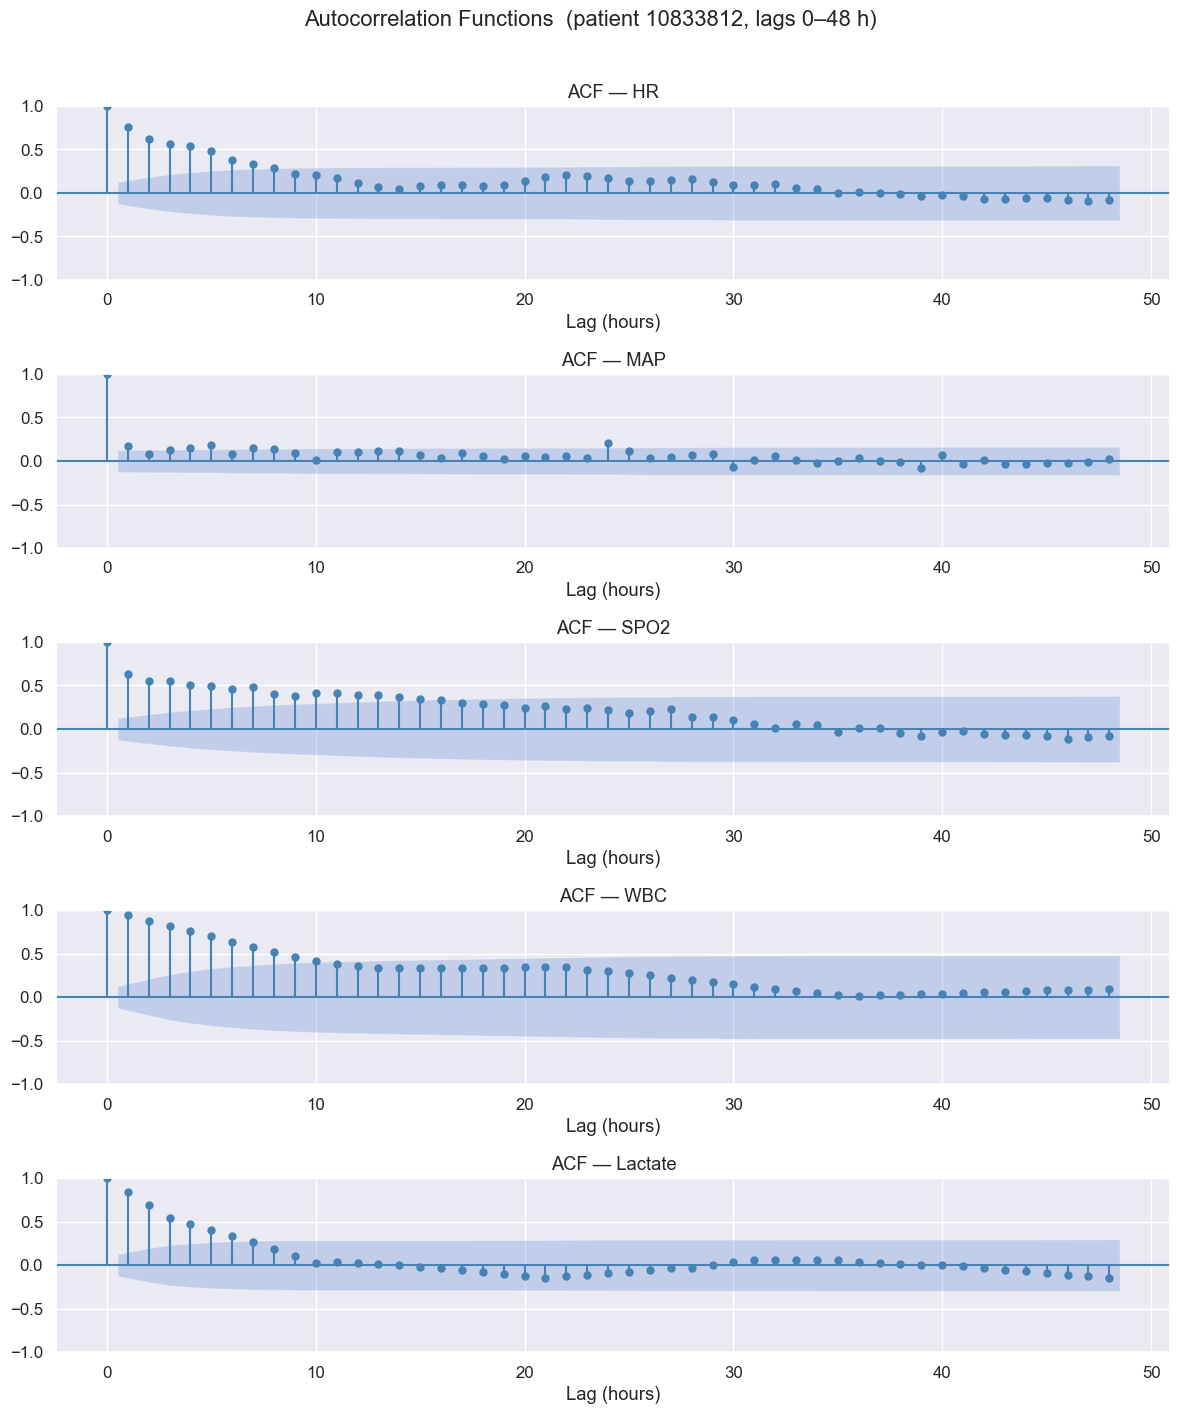

In [7]:
longest_id = df.groupby('SubjectId').size().idxmax()
pt = df[df['SubjectId'] == longest_id][continuous].ffill().bfill()

fig, axes = plt.subplots(len(continuous), 1, figsize=(12, 14))
for ax, col in zip(axes, continuous):
    plot_acf(pt[col].dropna(), lags=48, ax=ax, alpha=0.05,
             color='steelblue', vlines_kwargs={'colors': 'steelblue'})
    ax.set_title(f'ACF — {col}')
    ax.set_xlabel('Lag (hours)')

plt.suptitle(f'Autocorrelation Functions  (patient {longest_id}, lags 0–48 h)', y=1.01)
plt.tight_layout()
plt.show()

## 8. Stationarity — Augmented Dickey-Fuller Test

HMMs typically assume a stationary emission process. The ADF test checks this per-patient; the table shows what % of patients pass (p < 0.05 → stationary). Non-stationary features may need first-differencing or log-transforming before modelling.

,% stationary (p<0.05),median p-value
HR,48.2,0.0609
MAP,47.3,0.0766
SPO2,62.3,0.0107
WBC,9.2,0.4225
Lactate,51.6,0.0444


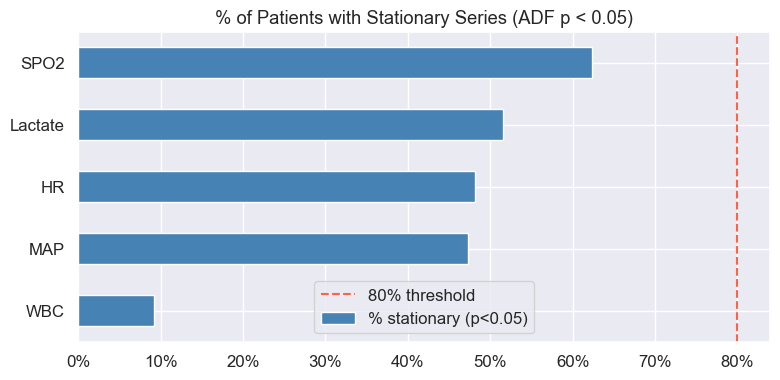

In [8]:
results = {}
for col in continuous:
    pvals = []
    for _, grp in df.groupby('SubjectId'):
        s = grp[col].dropna()
        if len(s) > 10:
            try:
                pvals.append(adfuller(s, autolag='AIC')[1])
            except Exception:
                pass
    if pvals:
        arr = np.array(pvals)
        results[col] = {
            '% stationary (p<0.05)': round(np.mean(arr < 0.05) * 100, 1),
            'median p-value':        round(np.median(arr), 4)
        }

adf_df = pd.DataFrame(results).T
display(adf_df)

fig, ax = plt.subplots(figsize=(8, 4))
adf_df['% stationary (p<0.05)'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(80, color='tomato', ls='--', label='80% threshold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('% of Patients with Stationary Series (ADF p < 0.05)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Flag Co-occurrence Over Normalised Stay

Do interventions cluster at particular points in the ICU stay? Plotting against normalised time (0 = admission, 1 = discharge) lets us compare across patients with different stay lengths.

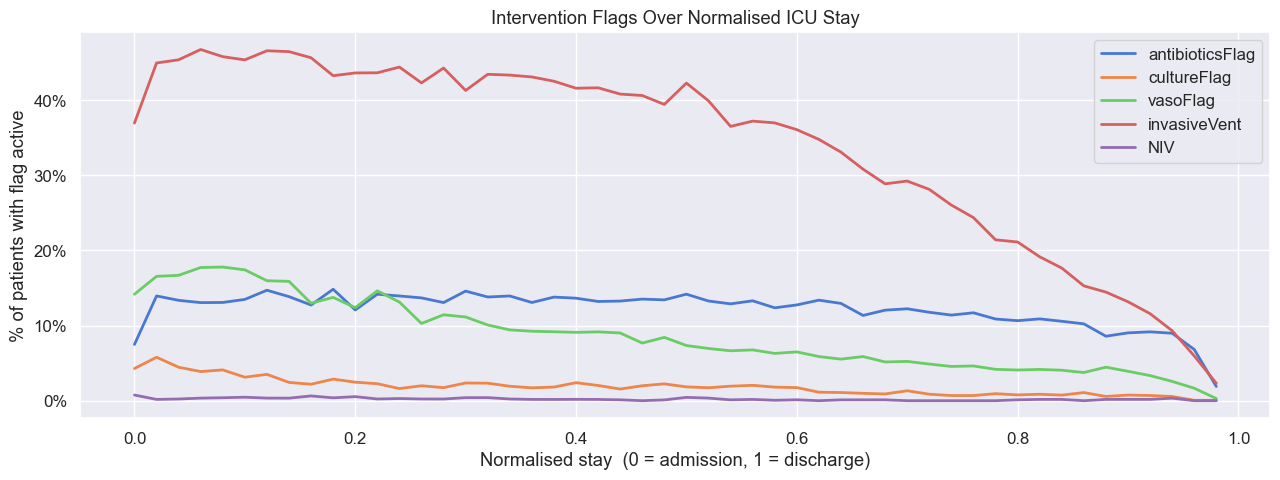

In [9]:
N_BINS  = 50
records = []

for _, grp in df.groupby('SubjectId'):
    n = len(grp)
    for i, (_, row) in enumerate(grp.iterrows()):
        t = i / (n - 1) if n > 1 else 0
        records.append({
            'norm_time':       t,
            'antibioticsFlag': row['antibioticsFlag'],
            'cultureFlag':     row['cultureFlag'],
            'vasoFlag':        row['vasoFlag'],
            'invasiveVent':    int(row['oxygenFlag'] == 2),
            'NIV':             int(row['oxygenFlag'] == 1),
        })

norm_df     = pd.DataFrame(records)
norm_df['bin'] = pd.cut(norm_df['norm_time'], bins=N_BINS, labels=False)
plot_flags  = ['antibioticsFlag', 'cultureFlag', 'vasoFlag', 'invasiveVent', 'NIV']
binned      = norm_df.groupby('bin')[plot_flags].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for flag, color in zip(plot_flags, sns.color_palette("muted", len(plot_flags))):
    ax.plot(binned.index / N_BINS, binned[flag] * 100, label=flag, color=color, lw=2)

ax.set_xlabel('Normalised stay  (0 = admission, 1 = discharge)')
ax.set_ylabel('% of patients with flag active')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Intervention Flags Over Normalised ICU Stay')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Correlation Matrix

High inter-feature correlations (|r| > 0.7) suggest using a **diagonal-covariance** Gaussian HMM to reduce parameter count, or applying PCA before fitting.

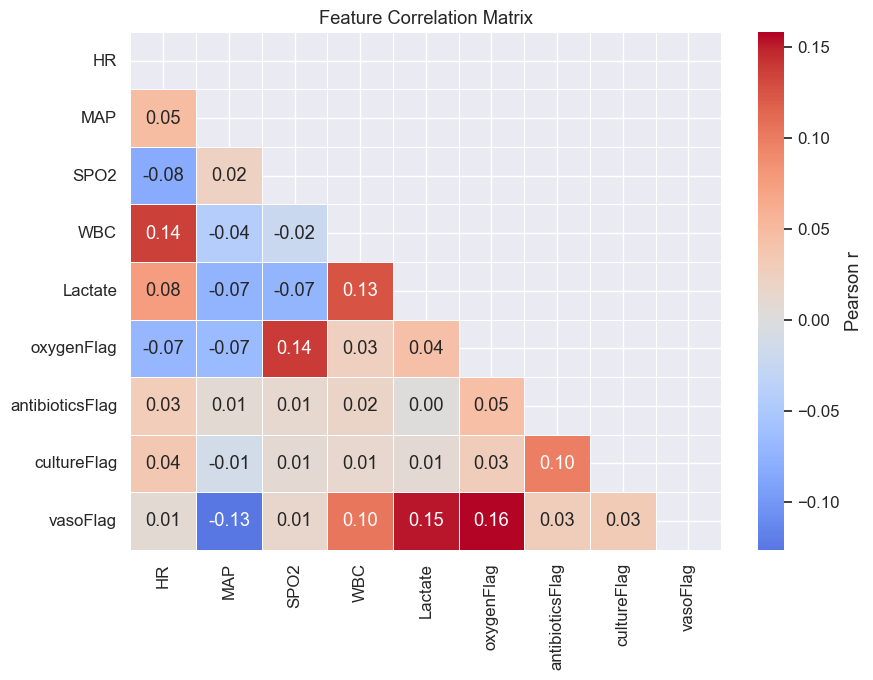

In [10]:
corr = df[continuous + flag_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()